## Colab 환경에서 실행 시 환경 설정

In [2]:
# 구글 드라이브의 폴더와 구글 코랩 폴더 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# 현재 경로 확인
!pwd

/content


In [4]:
# drive/MyDrive/경로로 변경
%cd drive/MyDrive

/content/drive/MyDrive


#### 코랩에서 한국어 표시하기

In [5]:
!pip install koreanize-matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 72.9 MB/s eta 0:00:00


In [6]:
import koreanize_matplotlib

In [15]:
import torch

print("CUDA 사용 가능 여부:", torch.cuda.is_available())  # True면 사용 가능
print("사용 가능한 GPU 개수:", torch.cuda.device_count())
print("현재 사용 중인 GPU:", torch.cuda.current_device())
print("GPU 이름:", torch.cuda.get_device_name(0))


CUDA 사용 가능 여부: True
사용 가능한 GPU 개수: 1
현재 사용 중인 GPU: 0
GPU 이름: Tesla T4


<hr>

<a id="lecture_index"></a>
# 🔖 다양한 분류 모델과 사전학습 모델

## 수업 목차
[1. 복습](#one)

[2. 다양한 이미지 분류 모델](#two)

[3. AlexNet 논문 소개 및 구현](#three)
- AlexNet 모델 특징
- AlexNet 영상 시청
- AlexNet 구조 시각화
- 논문 분석
- PyTorch로 구현하기

[4. VGG 구조 이해 및 구현](#four)
- VGG 모델 특징
- VGG 모델 시각화
- PyTorch로 구현하기

[5. 사전학습 모델 활용법](#five)
- 사전학습 모델 개념
- 사전학습 모델 찾는 법
- 사전학습 모델 불러오기
- 사전학습 모델을 활용한 추론

## <a id='one'>1️⃣ 복습 퀘스트 및 퀴즈</a>

- CNN
- Dataset
- Dataloader
- EarlyStopping  
- Checkpoint

Dataset
- 전처리를 쉽게 하기 위해서
- getitem이라는 메소드 사용 가능
- 다양한 데이터 타입을 다룰 수 있다 (동시에) -> 파이썬의 크랠스가 가지는 특징 때문에 가능한 것
- 데이터의 경로를 저장 / 배치 단위로 데이터를 불러올 수 있게 된다

In [ ]:
Dataloader
- 전처리를 쉽게 하기 위해서


In [ ]:
# cnn
# - con



## <a id='two'>2️⃣ 다양한 이미지 분류 모델</a>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

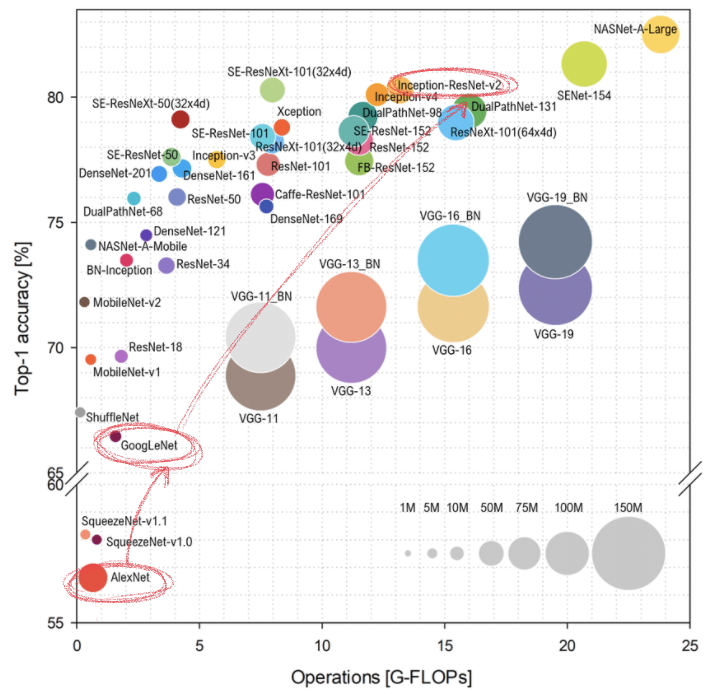

출처1: https://rubber-tree.tistory.com/120  <br>
출처2: https://arxiv.org/pdf/1810.00736 <br>
참고: https://paperswithcode.com/task/image-classification

## <a id='three'>3️⃣ AlexNet 논문 소개 및 구현</a>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### ✅ AlexNet 모델 특징
> 배경: 2009년 ImageNet 프로젝트가 처음 시작되었고 대규모 이미지 데이터 셋이 한창 모이고 있었음 <br>
> GPU 성능의 발전 <br>
> 이미지 분류 문제에서의 학계에서의 한계는 다음과 같았음. <br>
> 1. 이미지 데이터에서 특징을 추출하는 부분이 인간의 주관적 판단에 의존했음
> 2. 데이터가 복잡해지면 특징의 표현력이 한계에 부딪히는 문제가 있었음
> 3. 딥러닝 기반으로 학습을 하려고 해도 네트워크 깊이를 깊게 하면 과적합 문제가 발생했음
> 4. 네트워크 깊이가 깊어지면서 학습시간과 추론 시간이 급격히 늘어났음

#### 1️⃣ GPU를 활용한 대규모 딥러닝 학습
- AlexNet은 GPU 2대를 병렬로 사용하여 대용량 데이터셋(ImageNet)을 학습했음
- 당시 CPU만으로는 불가능했던 학습을 가능하게 함

#### 2️⃣ ReLU(Rectified Linear Unit) 도입
- 이전엔 sigmoid나 tanh를 주로 썼는데, AlexNet은 ReLU를 사용해 학습 속도와 성능 향상을 이끌어냄.

#### 3️⃣ Dropout 도입
- Fully Connected Layer에서 Dropout(랜덤으로 뉴런 제거)을 사용해 과적합 방지

#### 4️⃣ Data Augmentation 활용
- 이미지 데이터에 대해 수평 뒤집기, 랜덤 크롭, 밝기 조절 등을 적용해서 데이터 다양성 확보 → 일반화 성능 향상

#### 5️⃣ Overlapping MaxPooling 사용
- 기존 Pooling 보다 조금씩 겹쳐지게 하여 정보를 더 풍부하게 유지하고 성능을 개선

#### 6️⃣ Local Response Normalization(LRN)
- 생물학적 뇌의 측면 억제(lateral inhibition)를 모방하여 모델의 성능과 일반화 능력을 향상시킴
-  한 뉴런이 강하게 활성화될 때, 그 주변의 인접한 뉴런들의 활성도를 억제하는 메커니즘을 의미함. 주변보다 특정 자극에 강하게 반응하는 뉴런의 신호가 더 두드러지게 되어, 경계와 대비가 향상됩니다.
- 모델이 특정 채널에 과도하게 의존하는 것을 방지하고, 학습 초기에 빠르게 수렴하는 데 도움을 주며, 과적합을 완화하는 효과가 있음

### AlexNet 영상 시청

> 2:26 ~ 10:00

https://www.youtube.com/watch?v=UZDiGooFs54

### AlexNet 구조 시각화

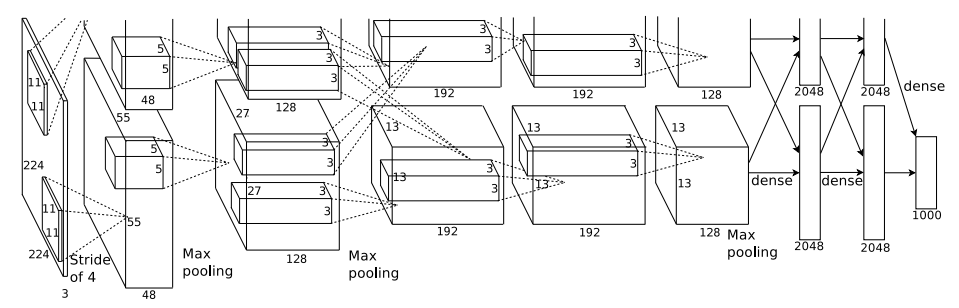

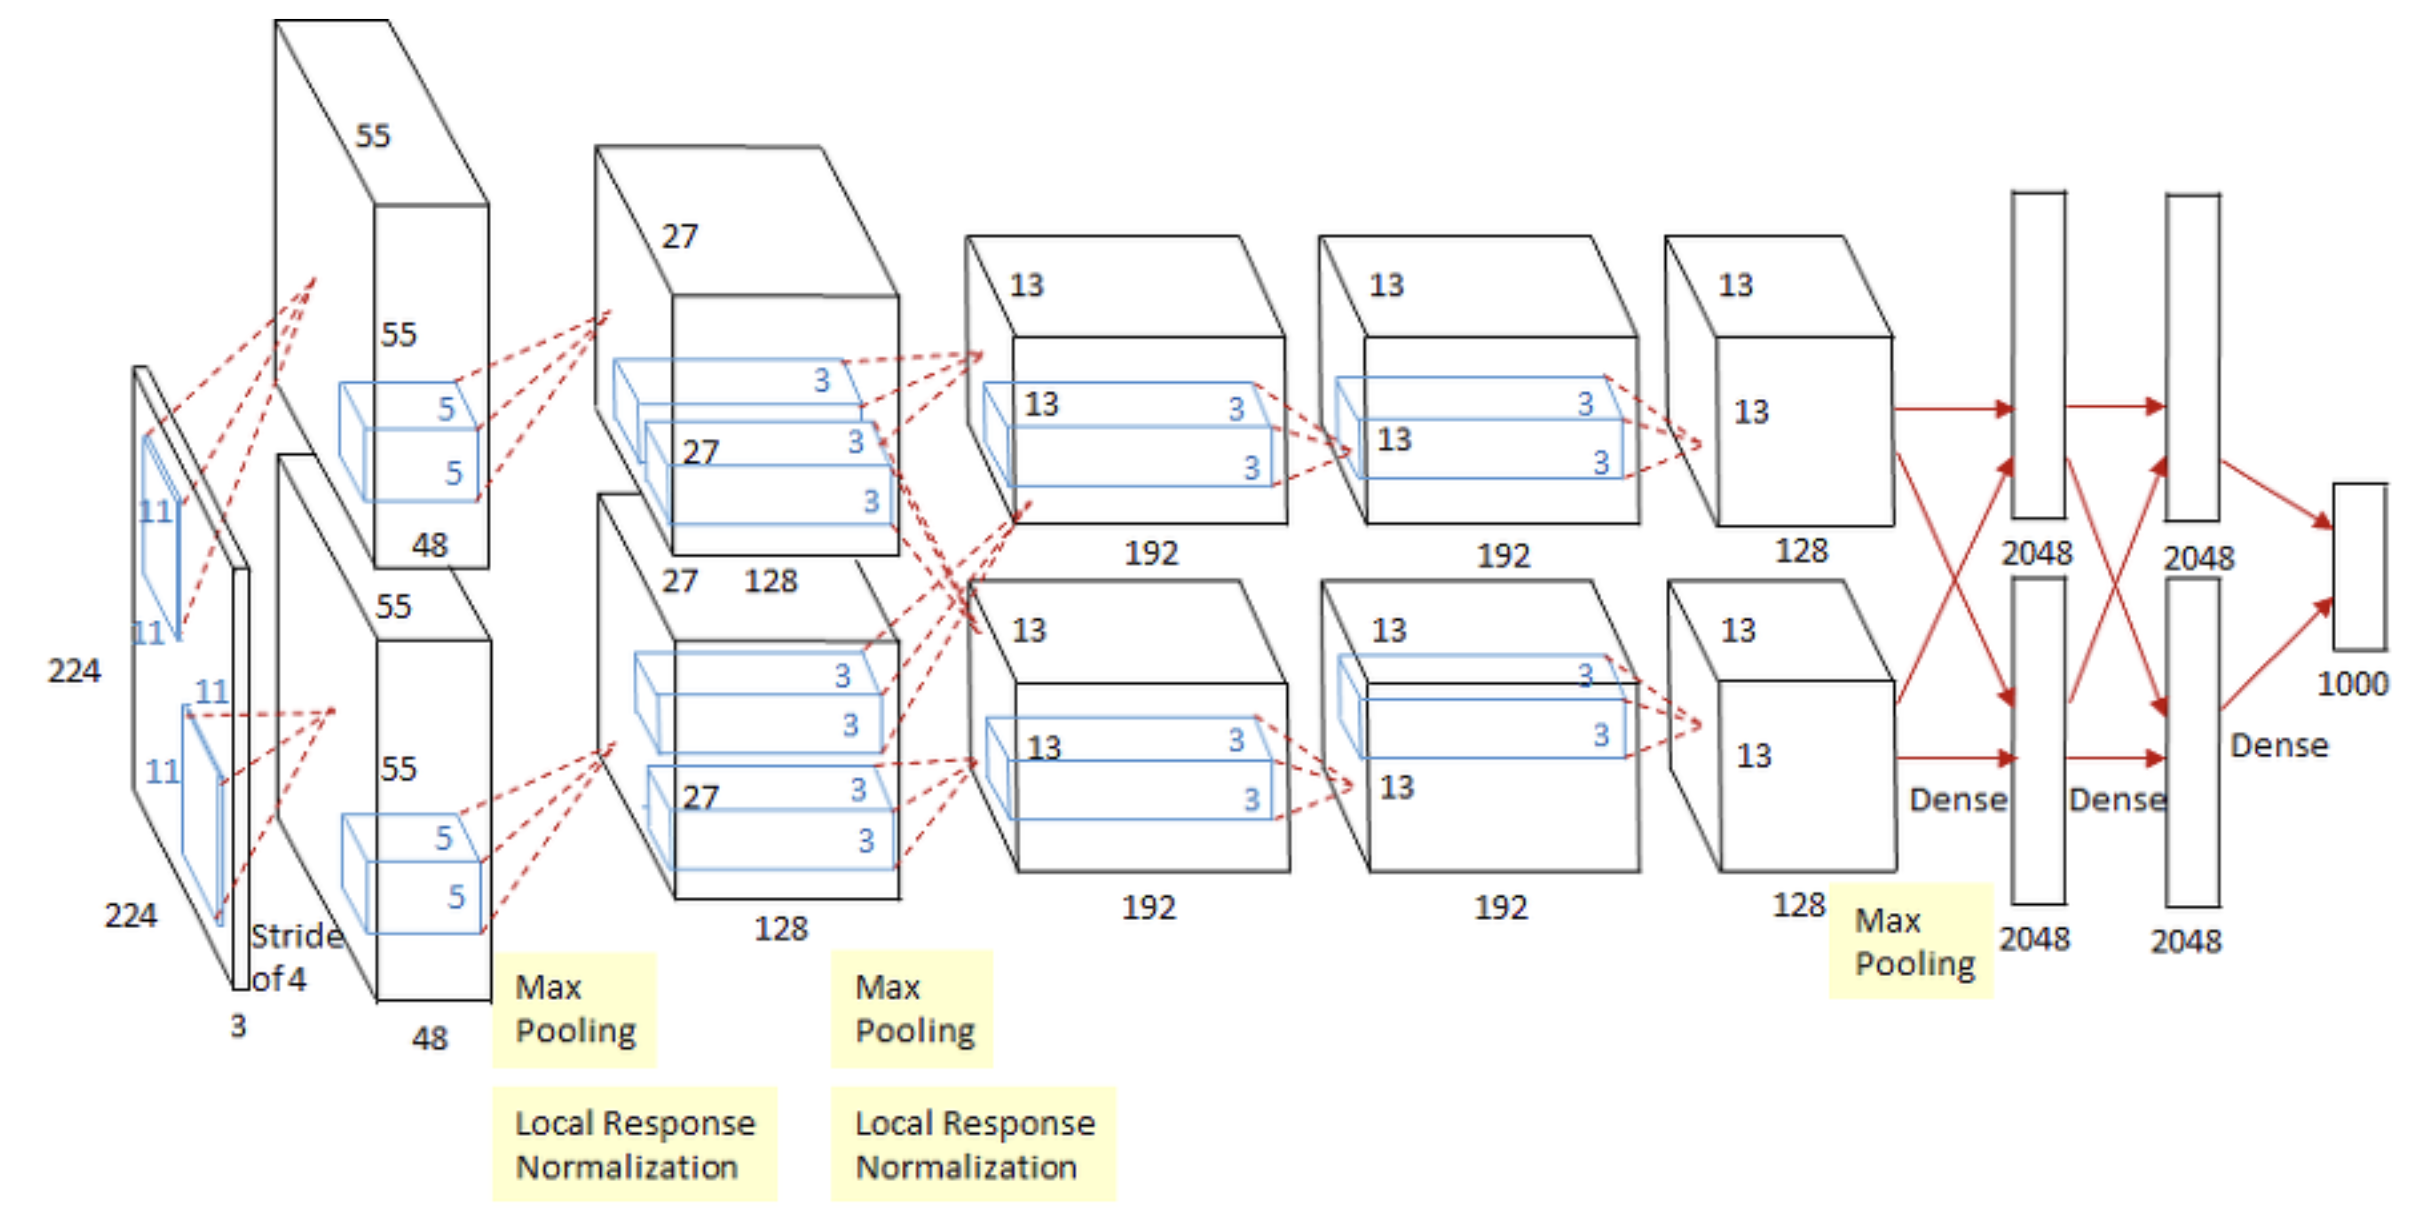

### 논문 분석

#### 용어

> 모든 shape -> (Height, Width, Channel) <br>
> kernel -> channel <br>
> top-1 error, top-5 error

#### 데이터 전처리
- 원본 비율 유지한 채로(짧은쪽을 고정) resize 후 중앙 이미지 crop   
- Mean subtraction

#### 데이터 증강
- translation (이동 연산)
- horizontal reflection (수평 뒤집기)
- PCA 기반 RGB 값 조절 (밝기 조절 또는 노이즈 추가)

#### 학습 세부 사항
- batch_size: 128
- SGD
1) momentum: 0.9
2) weight decay: 0.0005
2) learning rate: 0.01 (총 3번 학습률 감소 예정)
- weight initialization: zero-mean gaussian distribution (0.01)
1) conv layer 2, 4, 5번째, fc layer bias: 1
- epoch: 90

#### 구조
```
input_layer = 227x227x3  
conv1_layer1 = (55x55x48) / kernel_size=11x11 / stride=4
max_pool1_1 / stride = 2 / kernel_size = 3
conv1_layer2 = (55x55x48) / kernel_size=11x11 / stride=4
max_pool1_2 / stride = 2 / kernel_size = 3
conv2_layer1 = (27x27x128) / kernel_size=5x5 / stride=?
max_pool2_1 / stride = 2 / kernel_size = 3
conv2_layer2 = (27x27x128) / kernel_size=5x5 / stride=?
max_pool2_2 / stride = 2 / kernel_size = 3
conv3_layer1 = (13x13x192) / kernel_size=3x3 / stride=1 padding=2
conv3_layer2 = (13x13x192) / kernel_size=3x3 / stride=1 padding=2
conv4_layer1 = (13x13x192) / kernel_size=3x3 / stride=1 padding=2
conv4_layer2 = (13x13x192) / kernel_size=3x3 / stride=1 padding=2
conv5_layer1 = (13x13x128)
max_pool3_1 / stride = 2 / kernel_size = 3
conv5_layer2 = (13x13x128)
max_pool3_2 / stride = 2 / kernel_size = 3
fc1_layer1 = (2048, 2048)
fc1_layer2 = (2048, 2048)
fc2_layer1 = (2048, 1000)
fc2_layer2 = (2048, 1000)
```

출처: https://proceedings.neurips.cc/paper_files/paper/2012/file/c399862d3b9d6b76c8436e924a68c45b-Paper.pdf

### PyTorch로 구현해보기

In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "False"

In [7]:
from PIL import Image

In [ ]:
image = Image.open('./사진/bulbul.jpeg')

In [ ]:
image.size

(900, 675)

In [ ]:
resized_image = transforms(image)

In [56]:
import torch
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import transforms
from torchvision.datasets import CIFAR10

train_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=[0.1, 0.1]),
    transforms.RandomHorizontalFlip(0.5),  # 확률
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 밝기, 대비, 채도, 색조
    transforms.Resize(256),
    transforms.CenterCrop(227),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])
val_transform = transforms.Compose([
    transforms.RandomAffine(degrees=0, translate=[0.1, 0.1]),
    transforms.RandomHorizontalFlip(0.5),  # 확률
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),  # 밝기, 대비, 채도, 색조
    transforms.Resize(256),
    transforms.CenterCrop(227),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.4914, 0.4822, 0.4465], std=[0.2023, 0.1994, 0.2010])
])

subset_indices1 = list(range(1000))
subset_indices2 = list(range(100))

train_dataset = CIFAR10(root='./data', train=True, download=True, transform=train_transform)
val_dataset = CIFAR10(root='./data', train=False, download=True, transform=val_transform)

train_dataset = Subset(train_dataset, subset_indices1)
val_dataset = Subset(val_dataset, subset_indices2)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=True)

In [ ]:
transform1 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(256),
])

transform2 = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.CenterCrop(256),
])

In [57]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchsummary import summary

# Gradient vanishing -> 지금은 거의 극복된 문제
# Overfitting -> 과적합은 아직도 해결해야 하는 문제

class AlexNet(nn.Module):
    def __init__(self):
        super(AlexNet, self).__init__()
        self.feature_extractor = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=96, kernel_size=11, stride=4),
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, k=2, alpha=0.0001, beta=0.75),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=96, out_channels=256, kernel_size=5, stride=1, padding=2),
            nn.ReLU(),
            nn.LocalResponseNorm(size=5, k=2, alpha=0.0001, beta=0.75),
            nn.MaxPool2d(kernel_size=3, stride=2),

            nn.Conv2d(in_channels=256, out_channels=384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.Conv2d(in_channels=384, out_channels=384, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),

            nn.Conv2d(in_channels=384, out_channels=256, kernel_size=3, stride=1, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2)
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(6*6*256, 4096),
            nn.Linear(4096, 4096),
            nn.Linear(4096, 10),
        )

    def forward(self, x):
        feature = self.feature_extractor(x)
        fc = self.classifier(feature)
        return fc

# 모델 생성
alexnet = AlexNet()

In [28]:
summary(alexnet, (3, 227, 227), device='cpu')

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 96, 55, 55]          34,944
              ReLU-2           [-1, 96, 55, 55]               0
 LocalResponseNorm-3           [-1, 96, 55, 55]               0
         MaxPool2d-4           [-1, 96, 27, 27]               0
            Conv2d-5          [-1, 256, 27, 27]         614,656
              ReLU-6          [-1, 256, 27, 27]               0
 LocalResponseNorm-7          [-1, 256, 27, 27]               0
         MaxPool2d-8          [-1, 256, 13, 13]               0
            Conv2d-9          [-1, 384, 13, 13]         885,120
             ReLU-10          [-1, 384, 13, 13]               0
           Conv2d-11          [-1, 384, 13, 13]       1,327,488
             ReLU-12          [-1, 384, 13, 13]               0
           Conv2d-13          [-1, 256, 13, 13]         884,992
             ReLU-14          [-1, 256,

In [71]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
sgd = torch.optim.SGD(lr=0.01, momentum=0.9, weight_decay=0.0005, params=alexnet.parameters())  # SGD: 확률적 경사 하강법
scheduler = torch.optim.lr_scheduler.StepLR(sgd, step_size=30, gamma=0.1)   # step_size: epoch / gamma: learning rate 감소 비율
loss_fn = nn.CrossEntropyLoss()


def model_train(model, train_loader, val_loader, optimizer, loss_fn, scheduler, epochs=90):

    model.to(device)

    total_train_loss = []
    total_val_loss = []

    total_train_acc = []
    total_val_acc = []

    # 학습 루프
    for epoch in range(epochs):

        model.train()
        train_loss = 0
        train_acc = 0
        label_size = 0

        for images, labels in train_loader:     # 1000 / batch 100
            # 데이터 불러오기
            images, labels = images.to(device), labels.to(device)   # labels -> batch_size
            # 가중치 초기화
            optimizer.zero_grad()

            # 순전파
            outputs = model(images) # (batch_size, 10)

            # 오차구하기
            loss = loss_fn(outputs, labels)
            train_loss += loss.item()  # loss.item() : 텐서에서 숫자값을 가져옴

            # 역전파
            loss.backward()

            # 정답 확인
            train_acc += (torch.argmax(outputs, dim=1) == labels).sum().item()
            label_size += labels.size(0)

            # 가중치 업데이트
            optimizer.step()

        train_loss_per_epoch = train_loss / len(train_loader)
        train_acc_per_epoch = (train_acc / label_size) * 100

        total_train_loss.append(train_loss_per_epoch)
        total_train_acc.append(train_acc_per_epoch)


        # 검증 루프
        model.eval()
        val_loss = 0
        val_acc = 0
        label_size = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                # 예측
                outputs = model(images)

                # 오차 구하기 -> 과적합 방지 및 확인 용도로만 오차 구함
                loss = loss_fn(outputs, labels)
                val_loss += loss.item()

                # 정확도
                val_acc += (torch.argmax(outputs, dim=1) == labels).sum().item()
                label_size += labels.size(0)

            val_loss_per_epoch = val_loss / len(val_loader)
            val_acc_per_epoch = (val_acc / label_size) * 100

            total_val_loss.append(val_loss_per_epoch)
            total_val_acc.append(val_acc_per_epoch)

            scheduler.step()

            print(f"[{epoch+1}/{epochs}]"
                f"Train Loss: {train_loss_per_epoch}, Train Acc: {train_acc_per_epoch}% | "
                f"Val Loss: {val_loss_per_epoch}, Val Acc: {val_acc_per_epoch}%")


In [31]:
img, labels = next(iter(train_loader))

In [32]:
output = alexnet(img)

In [33]:
output


tensor([[ 0.0049, -0.0182,  0.0139, -0.0073, -0.0102, -0.0065, -0.0134, -0.0046,
          0.0066, -0.0153],
        [ 0.0054, -0.0169,  0.0168, -0.0093, -0.0076, -0.0117, -0.0188, -0.0047,
          0.0085, -0.0193],
        [ 0.0028, -0.0164,  0.0133, -0.0094, -0.0100, -0.0111, -0.0164, -0.0063,
          0.0086, -0.0162],
        [ 0.0012, -0.0142,  0.0172, -0.0108, -0.0095, -0.0084, -0.0207, -0.0073,
          0.0100, -0.0110],
        [ 0.0055, -0.0119,  0.0097, -0.0111, -0.0110, -0.0096, -0.0186, -0.0023,
          0.0080, -0.0181],
        [ 0.0052, -0.0189,  0.0165, -0.0119, -0.0093, -0.0112, -0.0179, -0.0093,
          0.0081, -0.0089],
        [ 0.0080, -0.0154,  0.0127, -0.0108, -0.0090, -0.0134, -0.0194, -0.0012,
          0.0093, -0.0138],
        [ 0.0092, -0.0161,  0.0166, -0.0125, -0.0167, -0.0077, -0.0173, -0.0034,
          0.0092, -0.0110],
        [ 0.0024, -0.0107,  0.0128, -0.0116, -0.0134, -0.0112, -0.0187, -0.0035,
          0.0078, -0.0141],
        [ 0.0082, -

In [ ]:
_, pred = torch.max(output, 1)
pred

tensor([5, 5, 5, 5, 5, 9, 5, 5, 9, 9, 5, 5, 5, 5, 5, 9, 5, 5, 5, 5, 5, 5, 5, 5,
        5, 5, 5, 5, 5, 9, 5, 5])

In [ ]:
torch.argmax(output)

tensor(105)

In [72]:
model_train(alexnet, train_loader, val_loader, sgd, loss_fn, scheduler, epochs=90)

[1/90]Train Loss: 1.6354870349168777, Train Acc: 38.6% | Val Loss: 1.633846789598465, Val Acc: 44.0%
[2/90]Train Loss: 1.676298126578331, Train Acc: 39.300000000000004% | Val Loss: 1.5769245326519012, Val Acc: 40.0%
[3/90]Train Loss: 1.6465471126139164, Train Acc: 38.4% | Val Loss: 1.7361262738704681, Val Acc: 39.0%
[4/90]Train Loss: 1.643170215189457, Train Acc: 40.0% | Val Loss: 1.571339190006256, Val Acc: 41.0%
[5/90]Train Loss: 1.5934329107403755, Train Acc: 41.0% | Val Loss: 1.6789762079715729, Val Acc: 40.0%
[6/90]Train Loss: 1.6260050497949123, Train Acc: 38.4% | Val Loss: 1.6643038094043732, Val Acc: 38.0%
[7/90]Train Loss: 1.5159916803240776, Train Acc: 43.9% | Val Loss: 1.7669923305511475, Val Acc: 41.0%
[8/90]Train Loss: 1.55794083699584, Train Acc: 43.2% | Val Loss: 1.6428966522216797, Val Acc: 41.0%
[9/90]Train Loss: 1.503697544336319, Train Acc: 43.8% | Val Loss: 1.5121607184410095, Val Acc: 49.0%
[10/90]Train Loss: 1.5129379332065582, Train Acc: 45.2% | Val Loss: 1.69891

KeyboardInterrupt: 

## <a id='four'>4️⃣ VGG 구조 이해 및 구현</a>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

### ✅ VGG 모델 특징
> VGG는 3x3 Conv 필터를 여러 번 쌓아 깊이를 늘려 성능 향상에 성공한 모델

#### 1️⃣ 3x3 Convolution을 반복해서 깊은 구조 구성
- 모든 Conv Layer는 3x3 필터, padding=1, stride=1 사용
- 여러 개를 쌓으면 receptive field가 커지면서 복잡한 패턴도 포착 가능
- 예: 3x3 2개 = 5x5, 3개 = 7x7 효과

#### 2️⃣ 층이 매우 깊은 CNN 구조
- 총 16개 레이어 (13 Conv + 3 FC)
- 모델이 깊어지면서 정교한 특징 추출 가능

#### 3️⃣ 일관된 구조와 단순한 설계
- 모든 블록이 거의 같은 패턴(Conv x2~3 → MaxPooling)
- 구조가 반복적이고 직관적이어서 구현·확장에 용이

#### 4️⃣ Feature Extractor로 많이 사용
- 단순하고 안정적인 구조 덕분에, 이후 다양한 모델의 백본(backbone)으로 자주 사용됨

#### 5️⃣ 파라미터 수가 매우 많음
- Fully Connected Layer에서 파라미터 수 폭증
- 약 138M(1억 3천만 개) → 연산량이 크고, 메모리 부담도 큼

출처: https://arxiv.org/pdf/1409.1556

### VGG 모델 시각화

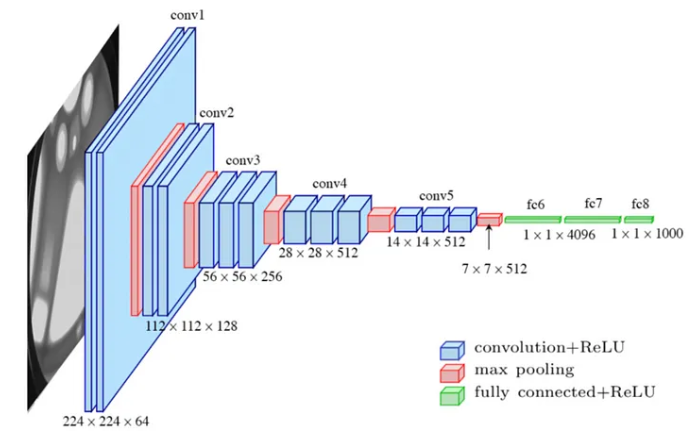

### 논문 분석

#### 용어
> receptive field -> kernel size <br>

#### 데이터 전처리
- Mean substraction (정규화)

#### 데이터 증강
- [Multi-scale traning] 원본 비율 유지한 채로(짧은쪽을 고정하지만 그 길이는 랜덤 선택{256, 384, ...}) Resize -> 랜덤 crop (고정 사이즈)
- Horizontal flip (수평 뒤집기)
- Random RGB Color shift (랜덤하게 밝기 조절)

#### 학습 세부 사항

- batch_size: 256
- SGD
1) momentum: 0.9
2) weight decay: 0.0005
2) learning rate: 0.01 (총 3번 학습률 감소 예정)
- dropout: 0.5
- epoch: 74

### PyTorch로 VGG 구현

In [ ]:
class VGG16(nn.Module):
    def __init__(self):
        super(VGG16, self).__init__()
        self.features = None
        self.classifier = None

    def forward(self, x):

        return x

## <a id='five'>5️⃣ 사전학습 모델 활용법</a>

<a href="#lecture_index">
    <span>⬆ 목차로</span>
</a>

## 사전학습 모델

> 사전학습 모델(pre-trained model)은 대규모 데이터로 사전에 학습된 신경망 모델 <br>
> 일반적으로 이 모델들은 특정 작업이나 데이터셋에 최적화되기 전에, 일반적인 패턴이나 특징을 학습함

참고: https://pytorch.org/vision/stable/models.html

### 사전학습 모델 찾는 법

In [ ]:
from timm import list_models # pip install timm

all_models = list_models()

In [ ]:
all_models

### 사전학습 모델 불러오기

In [ ]:
# @title
import pandas as pd
data = {
    "항목": [
        "목적", "결과", "가중치 적용", "전처리 접근", "유용한 상황", "활용 추천", "유연성",
    ],
    "get_model()": [
        "모델 구조 + 가중치 로딩",
        "nn.Module",
        '"DEFAULT" or Enum 지정',
        ".transforms() 가능",
        "표준적이고 깔끔한 사용",
        "⭐⭐⭐⭐⭐",
        "🟡 중간",
    ],
    "get_weight()": [
        "가중치 enum 객체만 가져옴",
        "Weights Enum 객체",
        "적용은 직접 해야 함",
        ".transforms() 포함",
        "가중치가 언제, 어떻게 학습되었는지 자세한 정보가 필요할 때",
        "⭐⭐⭐⭐☆",
        "🔴 낮음",
    ],
    "get_model_weights()": [
        "모델의 가중치 enum 목록 조회",
        "Enum 리스트",
        "적용은 직접 해야 함",
        "각 enum에 대해 접근 가능",
        "여러 가중치 비교 시",
        "⭐⭐⭐☆☆",
        "❌ 매우 낮음",
    ],
    "torch.hub.load()": [
        "GitHub 저장소에서 불러오기",
        "nn.Module",
        "weights='enum 단, 저장소마다 기본 가중치는 다름",
        "직접 구현 필요",
        "외부 논문/커스텀 모델 사용",
        "⭐⭐☆☆☆",
        "🚀 매우 높음",
    ],
    "클래스 방식 (models.resnet18)": [
        "모델 클래스 직접 불러오기",
        "nn.Module",
        "weights='enum'",
        "대부분 수동 구현",
        "기존 코드를 그대로 따라하거나 특정 레이어만 간단하게 수정해서 쓸 때",
        "⭐⭐⭐☆☆",
        "🟠 약간 높음",
    ],
    "Hugging Face 방식": [
        "Transformer, ViT 등 최신 모델 로딩",
        "HuggingFace 모델 객체",
        ".from_pretrained()",
        "자동 제공 (tokenizer 등)",
        "최신 모델을 불러오거나 바로 추론하거나 fine-tuning을 하고 싶을 때",
        "⭐⭐⭐⭐☆",
        "🟢 높음",
    ]
}
df1 = pd.DataFrame(data)

In [ ]:
# @title
import plotly.graph_objects as go # pip install plotly / pip install --upgrade nbformat

def show_table(df, width, height):
    header = list(df.columns)
    cells = [df[col] for col in df.columns]

    fig = go.Figure(data=[go.Table(
        header=dict(values=header, fill_color='paleturquoise', align='left'),
        cells=dict(values=cells, fill_color='lavender', align='left'))
    ])

    fig.update_layout(
        autosize=True,
        margin=dict(l=10, r=10, t=10, b=10),
        width=width,
        height=height
    )
    fig.show()

In [ ]:
show_table(df1, 1000, 400)

✅ enum
```
:정해진 값 외에는 바뀌지 않는 이름들의 집합
여기서 말하는 enum은 모델의 이름 집합
ex) vgg16, resnet50 등...
```

```
⭐⭐⭐⭐⭐: 실무, 연습 모두 추천 (공식 표준)
⭐⭐⭐⭐: 추천하는 방식이지만 약간의 제약/주의가 필요
⭐⭐⭐: 상황에 따라 쓰면 유용. 보조용으로 적합
⭐⭐: 고급 사용자에게 추천. 문서나 코드 구조를 분석할 수 있는 경우 사용
```

In [ ]:
from torchvision.models import get_model, get_weight, get_model_weights, resnet50, ResNet50_Weights

vgg16 = get_model("vgg16", weights=None)
pretrained_vgg16 = get_model("vgg16", weights="DEFAULT")

resnet50_enum = get_weight('ResNet50_Weights.DEFAULT') # ResNet50_Weights.DEFAULT와 동일 (Enum 객체)

# accuracy 76.130%
resnet1 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V1)
# accuracy 80.858%
resnet2 = resnet50(weights=ResNet50_Weights.IMAGENET1K_V2)
# 기본 모델 (IMAGENET1K_V2와 동일)
resnet3 = resnet50(weights=ResNet50_Weights.DEFAULT)
# 문자열로도 설정 가능
resnet4 = resnet50(weights="IMAGENET1K_V2")
# 랜덤으로 초기화된 모델 (사전학습 모델 X)
resnet5 = resnet50(weights=None)

In [ ]:
# 일반적인 패턴
vggs = get_model_weights('vgg16')
get_model('vgg16', weights=vggs.DEFAULT)

In [ ]:
# enum객체는 단순한 문자열이 아니라, 해당 모델의 가중치 url, 가중치에 맞는 이미지 전처리 함수, 정확도, 논문 링크, 클래스 정보와 같은 다양한 것들을 담고 있다
resnet50_enum.url, resnet50_enum.transforms(), resnet50_enum.meta

In [ ]:
weights_enum = get_model_weights('resnet50') # 모델의 이름을 통해서 사용 가능한 모든 모델 이름들을 알려줌

In [ ]:
for w in weights_enum:
    print(w)

In [ ]:
# repo_or_dir: Github 주소 + 태그(버전)
# model: 모델 이름
# force_reload=True -> 캐시된 모델을 가져오지 않고 최신으로 가져옴
# trust_repo: pytorch 저장소가 아닌 다른 저장소로 부터 다운 받을 때 사용
# 단, github 저장소 안에 hubconf.py 파일이 있는 경우만 다운로드 가능
resnet18 = torch.hub.load("pytorch/vision:v0.14.0", "resnet18")

### 전처리 방식은 언제 적용해야 하는 걸까?

In [ ]:
# @title
data = {
    "상황": [
        "모델 학습 (train)",
        "모델 추론 (inference)",
        "fine-tuning (사전학습 모델 재학습)",
        "feature 추출 용도"
    ],
    "전처리 필요 여부": [
        "🟢 꼭 필요",
        "🟢 꼭 필요",
        "🟠 필요",
        "🟠 필요"
    ],
    "이유": [
        "원래 데이터는 다양한 크기/범위를 가지므로 정규화, 리사이즈 필요",
        "학습과 동일한 데이터 분포로 넣어야 예측이 정확함",
        "base 모델이 학습한 데이터 분포 유지 필요",
        "전처리 안 하면 feature space가 일치하지 않음"
    ]
}

df2 = pd.DataFrame(data)

In [ ]:
show_table(df2, 1000, 170)

#### 🛠️ Feature space
> 가중치에 의해 정의되는 feature map의 숫자 공간 <br>
> 쉽게 말해, 데이터를 이해하는 방식을 모아 놓은 공간

### 꼭 필요는 뭐고 필요는 뭘까?

> fine-tuning 또는 feature 추출을 할 때도 전처리는 필수지만, 데이터 증강 처리는 필수 보다는 선택 쪽에 가깝다

### 모델 불러오기, 전처리 찾기 너무 불편한데 한 번에 하는 방법은 없나?

In [ ]:
from torchvision.models import get_model, get_weight

def load_model_with_transform(model_name: str, weight_name: str = "DEFAULT"):
    enum_key = f"{model_name.upper()}_Weights.{weight_name}"
    weights = get_weight(enum_key)
    model = get_model(model_name, weights=weights)
    transform = weights.transforms()

    return model, transform

### 사전학습 모델을 활용한 추론

In [ ]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open('사진/goldfish2.jpeg')

In [ ]:
img

In [ ]:
weights = ResNet50_Weights.DEFAULT
preprocess = weights.transforms()
img_transformed = preprocess(img)
img_tensor= torch.permute(img_transformed, (1, 2, 0))
img_ndarray = img_tensor.numpy()

In [ ]:
img_transformed.shape

In [ ]:
plt.imshow(img_ndarray)

In [ ]:
img_transformed = img_transformed.unsqueeze(0)

In [ ]:
with torch.no_grad():
    output = resnet2(img_transformed)

In [ ]:
output.shape

In [ ]:
predicted_class_index = output.argmax(dim=1).item()
predicted_class_name = weights.meta["categories"][predicted_class_index]

In [ ]:
predicted_class_index, predicted_class_name